In [8]:
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path
from matplotlib.patches import FancyArrowPatch
import matplotlib.patches as patches

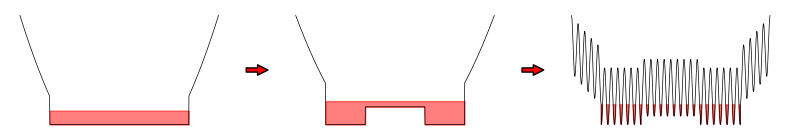

In [13]:
# Units:
#   a_lat = 1       (lattice constant)
#   V_lat = 1       (lattice depth)
xlim_plt = 15
x_sys = 4.5
x_rsv = 10.5
N_x_pt = 2000
V_rsv_offset = -0.3
a_har = 0.01        # Vx = a_har * x**2

V_har_at_edge = a_har * x_rsv**2 - 0.4
xrange = np.linspace(-xlim_plt, xlim_plt, N_x_pt)
Vx_lat = np.cos(xrange * 2 * np.pi)
Vx_har_and_box = np.where(abs(xrange) < x_rsv, V_har_at_edge, a_har * xrange**2)
Vx_rsv_offset = np.where(np.logical_and(abs(xrange) < x_rsv, abs(xrange) > x_sys), V_rsv_offset, 0)
Vx_tot_init = Vx_har_and_box 
Vx_tot_offset = Vx_har_and_box + Vx_rsv_offset
Vx_tot_lat = Vx_lat + Vx_har_and_box + Vx_rsv_offset

#%% Plots
mag_fig = 1
fig, (ax_init, ax_arr1, ax_offset, ax_arr2, ax_lat) = plt.subplots(1, 5,
    figsize = (8 * mag_fig, 1.5 * mag_fig), width_ratios = [8, 1, 8, 1, 8])
mu_init = 0.9
# ax_init = fig.add_subplot(131)
ax_init.plot(xrange, Vx_tot_init, color = "black", lw = 0.5 * mag_fig)
ax_init.fill_between(xrange, Vx_tot_init, mu_init, where = mu_init > Vx_tot_init
                     , color = "red", alpha = 0.5, ls = "None")
ax_init.set_axis_off()

mu_offset_on = 0.8
# ax_offset = fig.add_subplot(132)
ax_offset.plot(xrange, Vx_tot_offset, color = "black", lw = 0.5 * mag_fig)
ax_offset.fill_between(xrange, Vx_tot_offset, mu_offset_on, where = mu_offset_on > Vx_tot_offset
                       , color = "red", alpha = 0.5, ls = "None")
ax_offset.set_axis_off()

mu_lat_on = 0.1
# ax_lat = fig.add_subplot(133)
ax_lat.plot(xrange, Vx_tot_lat, color = "black", lw = 0.5 * mag_fig)
ax_lat.fill_between(xrange, Vx_tot_lat, mu_lat_on, where = mu_lat_on > Vx_tot_lat
                    , color = "red", alpha = 0.5, ls = "None")
ax_lat.set_axis_off()

for ax in [ax_arr1, ax_arr2]:
    ax.axis("off")
    arrow_ramp = FancyArrowPatch(posA = [0, 0.5], posB = [1, 0.5], 
                                edgecolor = "black",
                                facecolor = "red",
                                mutation_scale = 15)
    ax.add_patch(arrow_ramp)

fig.tight_layout()

thesis_fig_path = Path(r"C:\Users\ken92\Documents\Studies\E5\Theses\figures\flatband")
file_full_path = Path(thesis_fig_path, "exp_proposal.pdf")
fig.savefig(file_full_path, facecolor = "none", dpi = 300, bbox_inches='tight')